<a href="https://colab.research.google.com/github/luisferdm6/02_analisis_hotelero_pandas/blob/main/01_limpieza_y_agrupaciones_hotel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [90]:
import pandas as pd

url_dataset = "https://raw.githubusercontent.com/Rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"

df_real = pd.read_csv(url_dataset)

df_real.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [91]:
df_real.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [92]:
df_real.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [93]:
df_real ['children'] = df_real ['children'].fillna(0)

df_real ['children'].isnull().sum()

np.int64(0)

In [94]:
df_real = df_real.drop(columns=['company'], errors='ignore')

'company' in df_real.columns

False

In [95]:
df_real ['country'] = df_real ['country'].fillna('Unknown')

df_real ['country'].isnull().sum()

np.int64(0)

In [96]:
df_real ['agent'] = df_real ['agent'].fillna(0)

df_real ['agent'].isnull().sum()

np.int64(0)

In [97]:
df_real ['children'] = df_real ['children'].astype(int)

df_real ['agent'] = df_real ['agent'].astype(int)

df_real [['children', 'agent']].head()

,children,agent
0,0,0
1,0,0
2,0,0
3,0,304
4,0,240


In [98]:
df_real ['is_canceled'].value_counts()

,count
is_canceled,
0,75166
1,44224


In [99]:
df_real ['is_canceled'].value_counts(normalize=True) * 100

,proportion
is_canceled,
0,62.958372
1,37.041628


In [100]:
df_real.groupby('hotel') ['adr'].mean()

,adr
hotel,
City Hotel,105.304465
Resort Hotel,94.952930


In [101]:
df_sin_unknown = df_real[df_real['country'] != 'Unknown']

df_sin_unknown['country'].value_counts(normalize=True).map('{:.2%}'.format).head()

,proportion
country,
PRT,40.87%
GBR,10.20%
FRA,8.76%
ESP,7.21%
DEU,6.13%


In [102]:
df_real.groupby('is_canceled') ['lead_time'].mean()

,lead_time
is_canceled,
0,79.984687
1,144.848815


In [103]:
df_real.groupby('deposit_type') ['is_canceled'].mean() * 100

,is_canceled
deposit_type,
No Deposit,28.377022
Non Refund,99.362446
Refundable,22.222222


In [104]:
df_real['reservation_status_date'] = pd.to_datetime(df_real['reservation_status_date'])

In [105]:
df_real['reservation_status_date'].dtype

dtype('<M8[ns]')

In [106]:
df_real['status_year'] = df_real['reservation_status_date'].dt.year

In [107]:
df_real[['reservation_status_date','status_year']].head()

,reservation_status_date,status_year
0,2015-07-01,2015
1,2015-07-01,2015
2,2015-07-02,2015
3,2015-07-02,2015
4,2015-07-03,2015


In [108]:
df_real['status_day_name'] = df_real['reservation_status_date'].dt.day_name()

df_real['status_day_name'].value_counts(normalize=True).map('{:.2%}'.format)

,proportion
status_day_name,
Monday,15.66%
Friday,15.47%
Thursday,15.19%
Wednesday,15.03%
Tuesday,14.01%
Sunday,13.81%
Saturday,10.83%


In [109]:
#¿El lunes tiene más registros simplemente porque hay más salidas (Check-out), o es el día en que la gente MÁS CANCELA?

df_real.groupby('status_day_name')['is_canceled'].mean().map('{:.2%}'.format)

,is_canceled
status_day_name,
Friday,40.50%
Monday,43.18%
Saturday,23.68%
Sunday,16.13%
Thursday,38.91%
Tuesday,46.37%
Wednesday,45.34%


In [110]:
#¿Cuál es la tarifa promedio por noche según el tipo de hotel?

df_real.groupby('hotel')['adr'].mean().map('${:.2f}'.format)

,adr
hotel,
City Hotel,$105.30
Resort Hotel,$94.95


In [111]:
#¿Cuál es la tarifa promedio por noche dividida por tipo de hotel. Y al mismo tiempo por si la reserva fue cancelada o no?

df_real['is_canceled'] = df_real['is_canceled'].map({0: 'No', 1: 'Yes'})

df_real.groupby(['hotel','is_canceled'])['adr'].mean().map('${:.2f}'.format).reset_index()

,hotel,is_canceled,adr
0,City Hotel,No,$105.75
1,City Hotel,Yes,$104.69
2,Resort Hotel,No,$90.79
3,Resort Hotel,Yes,$105.79


In [112]:
df_ordenado = df_real.groupby('market_segment')['adr'].mean().reset_index().sort_values(by='adr', ascending=False)

df_ordenado['adr'] = df_ordenado['adr'].map('${:.2f}'.format)

df_ordenado

,market_segment,adr
6,Online TA,$117.20
3,Direct,$115.45
0,Aviation,$100.14
5,Offline TA/TO,$87.35
4,Groups,$79.48
2,Corporate,$69.36
7,Undefined,$15.00
1,Complementary,$2.89


In [113]:
#¿Cuál es el rango real de precios (piso, promedio y techo) al que estamos vendiendo en cada canal comercial, y qué tan rentable es cada canal?

resumen_tarifas = df_real.groupby('market_segment')['adr'].agg(['min','mean','max']).reset_index()

resumen_tarifas = resumen_tarifas.sort_values(by='mean',ascending=False)

resumen_tarifas[['min','mean','max']] = resumen_tarifas[['min','mean','max']].map('${:.2f}'.format)

resumen_tarifas

,market_segment,min,mean,max
6,Online TA,$0.00,$117.20,$450.00
3,Direct,$0.00,$115.45,$451.50
0,Aviation,$0.00,$100.14,$193.50
5,Offline TA/TO,$0.00,$87.35,$5400.00
4,Groups,$-6.38,$79.48,$367.00
2,Corporate,$0.00,$69.36,$508.00
7,Undefined,$12.00,$15.00,$18.00
1,Complementary,$0.00,$2.89,$170.00


In [114]:
#Detectando anomalias

df_real[df_real['adr'] > 5000][['hotel', 'is_canceled', 'reserved_room_type', 'adults', 'children', 'adr']]

,hotel,is_canceled,reserved_room_type,adults,children,adr
48515,City Hotel,Yes,A,2,0,5400.0


In [115]:
df_real[df_real['adr'] < 0][['hotel', 'is_canceled', 'reserved_room_type', 'adults', 'children', 'adr']]

,hotel,is_canceled,reserved_room_type,adults,children,adr
14969,Resort Hotel,No,A,2,0,-6.38


In [116]:
df_real = df_real[(df_real['adr'] >= 0) & (df_real['adr'] < 5000)]

df_real.shape

(119388, 33)

In [117]:
#Comprobación de corrección de anomalías

resumen_limpio = df_real.groupby('market_segment')['adr'].agg(['min','mean','max']).reset_index()

resumen_limpio = resumen_limpio.sort_values(by='mean',ascending=False)

resumen_limpio[['min','mean','max']] = resumen_limpio[['min','mean','max']].map('${:.2f}'.format)

resumen_limpio

,market_segment,min,mean,max
6,Online TA,$0.00,$117.20,$450.00
3,Direct,$0.00,$115.45,$451.50
0,Aviation,$0.00,$100.14,$193.50
5,Offline TA/TO,$0.00,$87.14,$510.00
4,Groups,$0.00,$79.48,$367.00
2,Corporate,$0.00,$69.36,$508.00
7,Undefined,$12.00,$15.00,$18.00
1,Complementary,$0.00,$2.89,$170.00


In [118]:
#¿Cuánto tiempo se queda realmente un huésped en cada tipo de hotel y qué perfil de viaje (de paso, negocios o vacaciones) domina cada propiedad?

df_real['total_stay'] = df_real['stays_in_week_nights'] + df_real['stays_in_weekend_nights']

df_real.groupby('hotel')['total_stay'].agg(['min','mean','max']).reset_index()

,hotel,min,mean,max
0,City Hotel,0,2.978167,57
1,Resort Hotel,0,4.318405,69


In [119]:
#¿Cuánto dinero real en ingresos por habitación generó cada hotel con las estancias efectivas (no canceladas)?

df_real['total_cost'] = df_real['total_stay'] * df_real['adr']

ingresos_hotel = df_real[df_real['is_canceled'] == 'No'].groupby('hotel')['total_cost'].sum().reset_index()

ingresos_hotel['total_cost'] = ingresos_hotel['total_cost'].map('${:,.2f}'.format)

ingresos_hotel

,hotel,total_cost
0,City Hotel,"$14,394,410.18"
1,Resort Hotel,"$11,601,914.03"


In [120]:
#¿Cuál de los dos hoteles tiene una fuga financiera más grave por cancelaciones?

ingresos_perdidos = df_real[df_real['is_canceled'] == 'Yes'].groupby('hotel')['total_cost'].sum().reset_index()

ingresos_perdidos['total_cost'] = ingresos_perdidos['total_cost'].map('${:,.2f}'.format)

ingresos_perdidos

,hotel,total_cost
0,City Hotel,"$10,879,659.78"
1,Resort Hotel,"$5,842,177.34"


In [121]:
#¿Qué porcentaje exacto de todas las reservas recibidas termina en cancelación en cada hotel?

df_real['cancelada_num'] = df_real['is_canceled'] == 'Yes'

tasa_cancelacion = df_real.groupby('hotel')['cancelada_num'].mean().map('{:.2%}'.format).reset_index()

tasa_cancelacion

,hotel,cancelada_num
0,City Hotel,41.73%
1,Resort Hotel,27.76%


In [122]:
#Ya sabemos que el City Hotel tiene un 41.73% de cancelaciones. Pero, ¿a través de qué canal comercial están llegando los clientes más informales y canceladores?

tasa_segmento = df_real.groupby('market_segment')['cancelada_num'].mean().sort_values(ascending=False).map('{:.2%}'.format).reset_index()

tasa_segmento

,market_segment,cancelada_num
0,Undefined,100.00%
1,Groups,61.07%
2,Online TA,36.72%
3,Offline TA/TO,34.31%
4,Aviation,21.94%
5,Corporate,18.73%
6,Direct,15.34%
7,Complementary,13.06%


In [123]:
#¿Cuántas reservas totales tenía realmente el canal Undefined que marcaba 100%?

#¿Cuál es el canal que aporta el mayor volumen de clientes al hotel?

total_reservas = df_real.groupby('market_segment').agg(
    total_reservas = ('is_canceled','count'),
    cancelaciones = ('cancelada_num','sum'),
    tasa_cancelacion = ('cancelada_num','mean')
).reset_index()

total_reservas = total_reservas.sort_values(by='total_reservas',ascending=False)

total_reservas['tasa_cancelacion'] = total_reservas['tasa_cancelacion'].map('{:.2%}'.format)

total_reservas


,market_segment,total_reservas,cancelaciones,tasa_cancelacion
6,Online TA,56477,20739,36.72%
5,Offline TA/TO,24218,8310,34.31%
4,Groups,19810,12097,61.07%
3,Direct,12606,1934,15.34%
2,Corporate,5295,992,18.73%
1,Complementary,743,97,13.06%
0,Aviation,237,52,21.94%
7,Undefined,2,2,100.00%


In [124]:
#¿Con cuántos días de anticipación reservan las personas que sí se quedan a dormir en comparación con las que terminan cancelando?

anticipacion_cancelacion = df_real.groupby('is_canceled')['lead_time'].agg(['mean','median']).reset_index()

anticipacion_cancelacion

,is_canceled,mean,median
0,No,79.983157,45.0
1,Yes,144.851299,113.0


In [125]:
#Si los clientes reservan con 4 meses de anticipación y cancelan de forma masiva... ¿por qué se dan ese lujo sin temor a perder dinero? ¿Qué tipo de garantía o anticipo les estamos pidiendo?

resumen_deposito = df_real.groupby('deposit_type').agg(
    total_reservas = ('is_canceled','count'),
    cancelaciones = ('cancelada_num','sum'),
    tasa_cancelacion = ('cancelada_num','mean')
).sort_values(by='total_reservas', ascending=False).reset_index()

resumen_deposito['tasa_cancelacion'] = resumen_deposito['tasa_cancelacion'].map('{:.2%}'.format)

resumen_deposito

,deposit_type,total_reservas,cancelaciones,tasa_cancelacion
0,No Deposit,104640,29694,28.38%
1,Non Refund,14586,14493,99.36%
2,Refundable,162,36,22.22%


In [126]:
#¿Los clientes recurrentes (huéspedes que ya nos conocen y han visitado el hotel antes) son más confiables que los clientes primerizos? ¿Qué tasa de cancelación tiene cada grupo?

resumen_lealtad = df_real.groupby('is_repeated_guest').agg(
    total_reservas = ('is_canceled','count'),
    cancelaciones = ('cancelada_num','sum'),
    tasa_cancelacion = ('cancelada_num','mean')
).reset_index()

resumen_lealtad['is_repeated_guest'] = resumen_lealtad['is_repeated_guest'].map({0 : 'No', 1 : 'Yes'})

resumen_lealtad['tasa_cancelacion'] = resumen_lealtad['tasa_cancelacion'].map('{:.2%}'.format)

resumen_lealtad

,is_repeated_guest,total_reservas,cancelaciones,tasa_cancelacion
0,No,115579,43671,37.78%
1,Yes,3809,552,14.49%


In [127]:
import matplotlib.pyplot as plt

import seaborn as sns


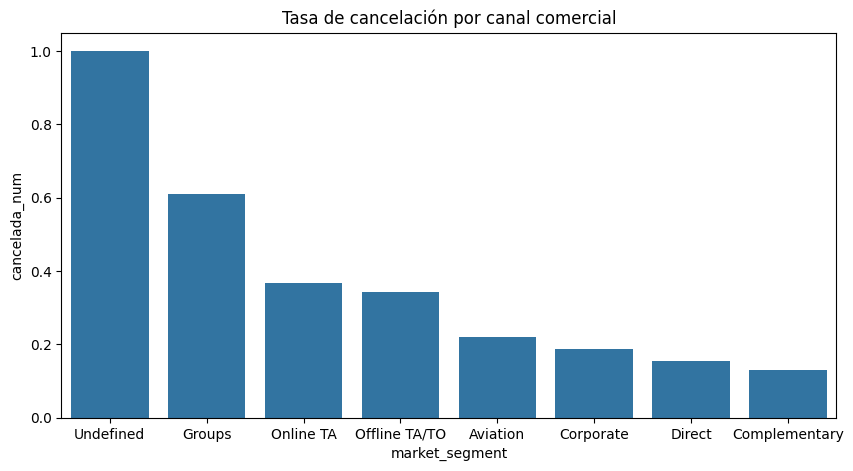

In [128]:
datos_grafica = df_real.groupby('market_segment')['cancelada_num'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=datos_grafica, x='market_segment', y='cancelada_num')
plt.title('Tasa de cancelación por canal comercial')
plt.show()

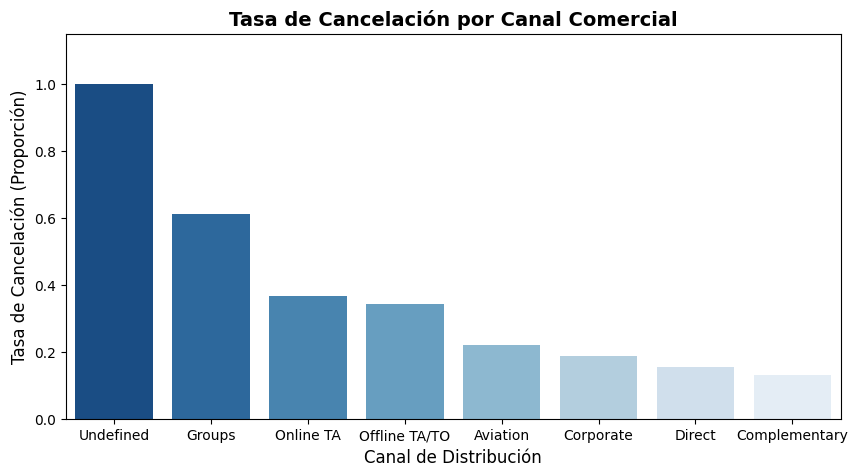

In [129]:
plt.figure(figsize=(10, 5))
sns.barplot(data=datos_grafica, x='market_segment', y='cancelada_num', palette='Blues_r', hue='market_segment', legend=False)
plt.title('Tasa de Cancelación por Canal Comercial', fontsize=14, fontweight='bold')
plt.xlabel('Canal de Distribución', fontsize=12)
plt.ylabel('Tasa de Cancelación (Proporción)', fontsize=12)
plt.ylim(0, 1.15)
plt.show()

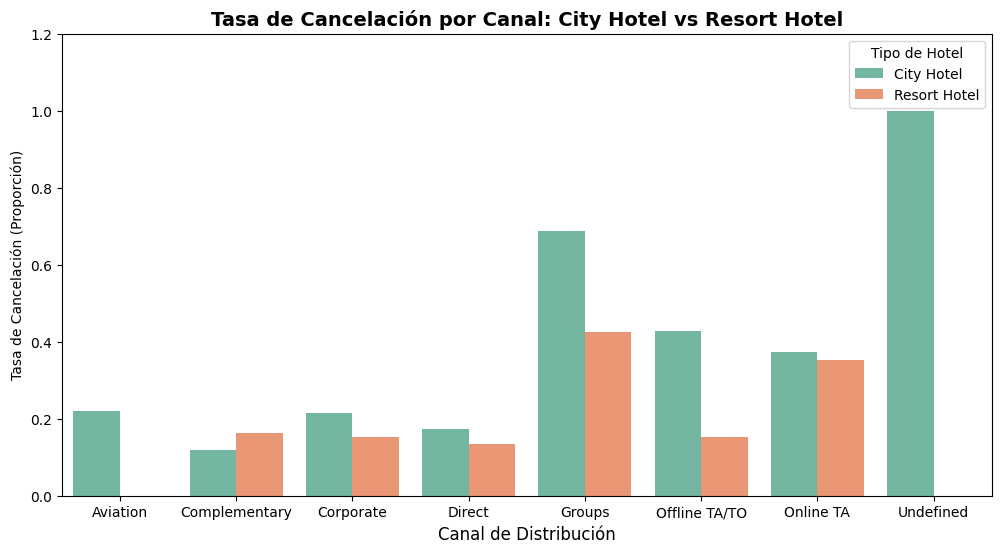

In [130]:
#Ya vimos que los grupos y las agencias en línea tienen tasas altas de cancelación. Pero, ¿este problema impacta por igual al City Hotel y al Resort Hotel, o uno de ellos está en situación crítica?

comparativa_tabla = df_real.groupby(['market_segment', 'hotel'])['cancelada_num'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=comparativa_tabla,
    x='market_segment',
    y='cancelada_num',
    hue='hotel',
    palette='Set2'
)
plt.title(
    'Tasa de Cancelación por Canal: City Hotel vs Resort Hotel',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Canal de Distribución', fontsize=12)
plt.ylabel('Tasa de Cancelación (Proporción)')
plt.ylim(0,1.2)
plt.legend(title='Tipo de Hotel')
plt.show()

In [131]:
#¿En qué meses del año el hotel logra cobrar la tarifa promedio por noche más alta a los huéspedes que efectivamente se quedan a dormir?

reservas_validas = df_real[df_real['is_canceled']=='No']

precio_mensual = reservas_validas.groupby('arrival_date_month')['adr'].mean().sort_values(ascending=False).reset_index()

precio_mensual['adr'] = precio_mensual['adr'].map('${:.2f}'.format)

precio_mensual

,arrival_date_month,adr
0,August,$142.09
1,July,$129.25
2,June,$114.59
3,September,$107.28
4,May,$104.84
5,April,$97.88
6,October,$86.83
7,December,$78.92
8,March,$77.34
9,February,$72.42


In [132]:
#Ya sabemos que Agosto es el mes más caro a nivel global ($142.09). Pero, ¿este aumento en verano se debe al Resort Hotel (playa/vacacional) o el City Hotel (negocios/urbano) también sube sus precios al mismo nivel?

adr_por_hotel = reservas_validas.groupby(['hotel', 'arrival_date_month'])['adr'].mean().sort_values(ascending=False).reset_index()

adr_por_hotel[adr_por_hotel['arrival_date_month'] == 'August']


,hotel,arrival_date_month,adr
0,Resort Hotel,August,181.205892
3,City Hotel,August,118.412083


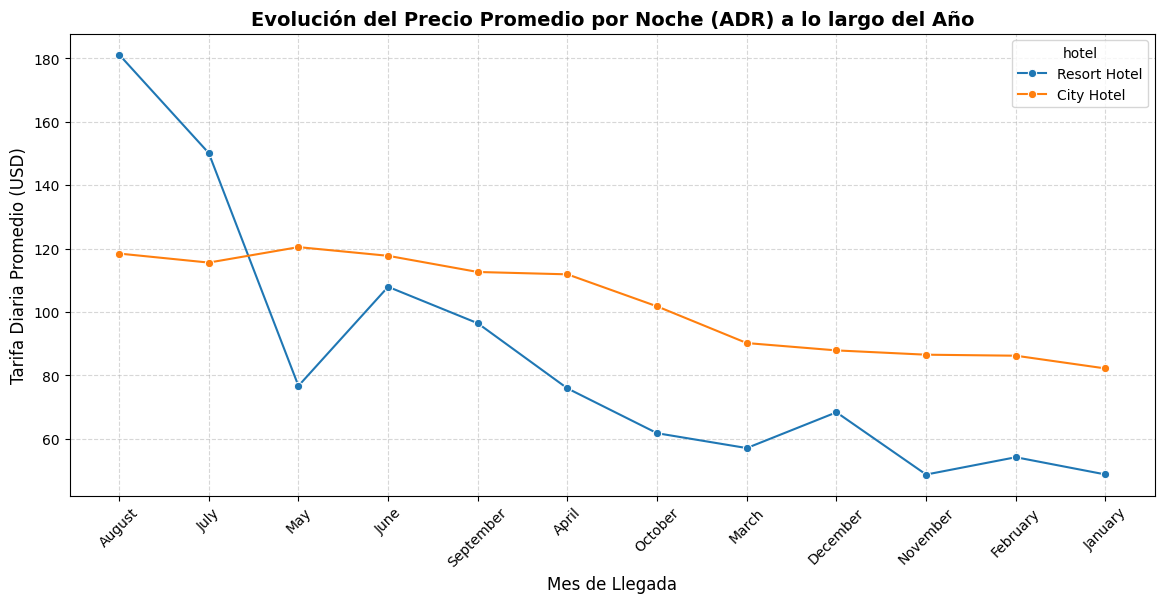

In [133]:
plt.figure(figsize=(14,6))
sns.lineplot(
    data=adr_por_hotel,
    x='arrival_date_month',
    y='adr',
    hue='hotel',
    marker='o'
)
plt.title(
    'Evolución del Precio Promedio por Noche (ADR) a lo largo del Año',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Mes de Llegada', fontsize=12)
plt.ylabel('Tarifa Diaria Promedio (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [134]:
reservas_validas = df_real[df_real['is_canceled'] == 'No'].copy()

orden_meses = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December',
]

reservas_validas['arrival_date_month'] = pd.Categorical(reservas_validas['arrival_date_month'], categories=orden_meses, ordered=True)

adr_por_hotel = (reservas_validas.groupby(['hotel', 'arrival_date_month'], observed=True)['adr'].mean().reset_index())



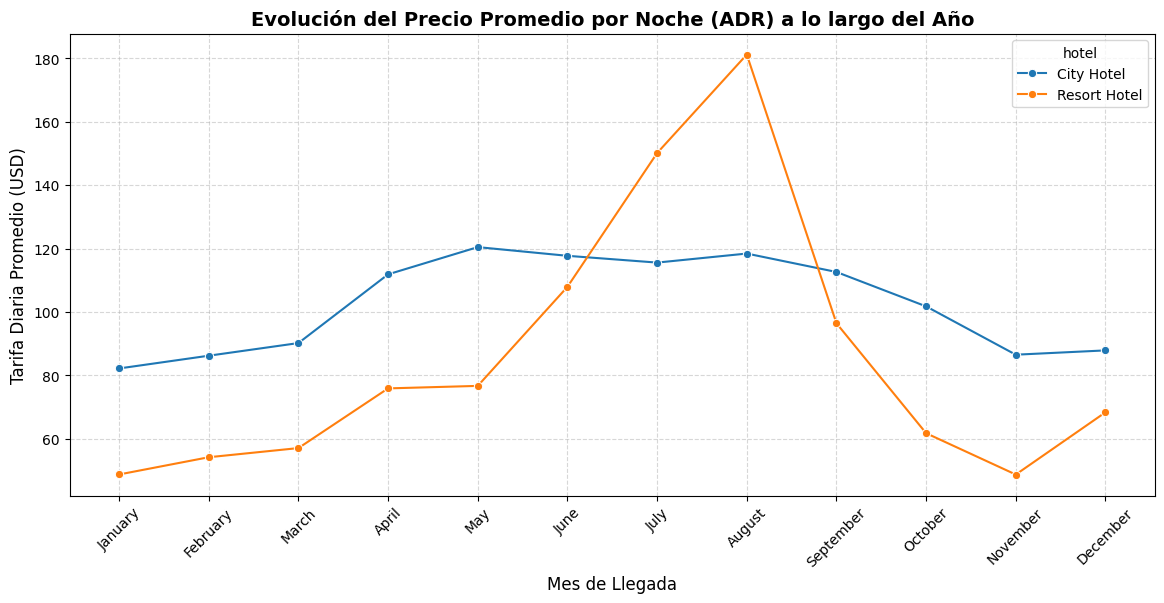

In [135]:
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=adr_por_hotel,
    x='arrival_date_month',
    y='adr',
    hue='hotel',
    marker='o',
)
plt.title(
    'Evolución del Precio Promedio por Noche (ADR) a lo largo del Año',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Mes de Llegada', fontsize=12)
plt.ylabel('Tarifa Diaria Promedio (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [136]:
#¿Agosto es también el mes en el que recibimos a más personas, o el volumen de clientes se concentra en otra época del año?

ocupacion_mensual = reservas_validas.groupby('arrival_date_month', observed=True)['hotel'].count().reset_index()

ocupacion_mensual.columns = ['Mes', 'Total_Huespedes']

ocupacion_mensual

,Mes,Total_Huespedes
0,January,4122
1,February,5372
2,March,6644
3,April,6565
4,May,7114
5,June,6404
6,July,7919
7,August,8638
8,September,6392
9,October,6914


In [137]:
#¿De qué 5 países proviene la mayor cantidad de clientes que realmente se hospedan con nosotros?

Top_Paises = reservas_validas['country'].value_counts().head().reset_index()

Top_Paises.columns = ['Pais', 'Total_Reservas']

Top_Paises

,Pais,Total_Reservas
0,PRT,21071
1,GBR,9675
2,FRA,8481
3,ESP,6391
4,DEU,6069


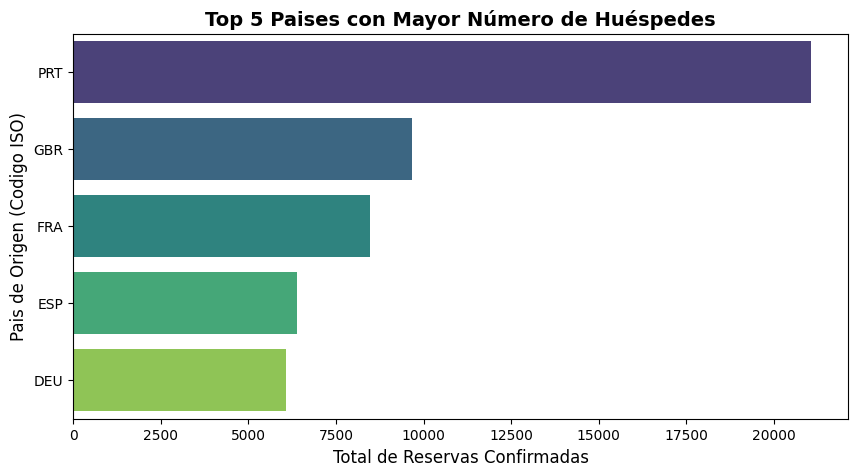

In [138]:
plt.figure(figsize=(10, 5))
sns.barplot(data=Top_Paises, x='Total_Reservas', y='Pais', palette='viridis', hue='Pais', legend=False)
plt.title('Top 5 Paises con Mayor Número de Huéspedes', fontsize=14, fontweight='bold')
plt.xlabel('Total de Reservas Confirmadas', fontsize=12)
plt.ylabel('Pais de Origen (Codigo ISO)', fontsize=12)
plt.show()

In [139]:
#¿A través de qué canales o segmentos de mercado nos llega la mayor cantidad de clientes?

segmentos_mercado = df_real['market_segment'].value_counts().reset_index()

segmentos_mercado

,market_segment,count
0,Online TA,56477
1,Offline TA/TO,24218
2,Groups,19810
3,Direct,12606
4,Corporate,5295
5,Complementary,743
6,Aviation,237
7,Undefined,2


In [140]:
traduccion_inversa = {'Yes' : 1, 'No' : 0}
df_real['is_canceled'] = df_real['is_canceled'].map(traduccion_inversa)

In [141]:
#Online TA nos trae 56,477 reservas, pero ¿cuántas de ellas realmente se quedan y cuántas nos cancelan? ¿Cuál es el canal con mayor riesgo de cancelación?

cancelacion_por_segmento = df_real.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False).map('{:.2%}'.format).reset_index()

cancelacion_por_segmento

,market_segment,is_canceled
0,Undefined,100.00%
1,Groups,61.07%
2,Online TA,36.72%
3,Offline TA/TO,34.31%
4,Aviation,21.94%
5,Corporate,18.73%
6,Direct,15.34%
7,Complementary,13.06%


In [142]:
#Ya sabemos que Groups cancela mucho (61.07%) y Direct cancela poco (15.34%). De las reservas efectivas que sí se hospedaron, ¿qué canal paga la tarifa promedio diaria más alta y cuál la más baja?

adr_por_segmento = reservas_validas.groupby('market_segment')['adr'].mean().sort_values(ascending=False).map('${:.2f}'.format).reset_index()

adr_por_segmento

,market_segment,adr
0,Direct,$113.88
1,Online TA,$113.86
2,Aviation,$99.48
3,Offline TA/TO,$83.42
4,Groups,$77.14
5,Corporate,$67.11
6,Complementary,$3.08


In [143]:
#¿Con cuántos días de anticipación reserva cada canal?

anticipacion_por_segmento = df_real.groupby('market_segment')['lead_time'].mean().sort_values(ascending=False).round(2).reset_index()

anticipacion_por_segmento

,market_segment,lead_time
0,Groups,186.97
1,Offline TA/TO,135.01
2,Online TA,83.00
3,Direct,49.86
4,Corporate,22.13
5,Complementary,13.29
6,Aviation,4.44
7,Undefined,1.50


In [144]:
#¿Un cliente que hace solicitudes especiales (cuna para bebé, cama extra, piso alto) tiene menor probabilidad de cancelar que uno que no pide nada?

peticiones_vs_cancelacion = df_real.groupby('total_of_special_requests')['is_canceled'].mean().sort_values(ascending=False).map("{:.2%}".format).reset_index()

peticiones_vs_cancelacion

,total_of_special_requests,is_canceled
0,0,47.72%
1,2,22.10%
2,1,22.02%
3,3,17.86%
4,4,10.59%
5,5,5.00%


In [145]:
#¿Qué tipo de cliente concentra la mayor tasa de cancelación y cómo se distribuye respecto a los demás perfiles?

cancelacion_por_tipo_de_cliente = df_real.groupby('customer_type')['is_canceled'].mean().sort_values(ascending=False).map("{:.2%}".format).reset_index()

cancelacion_por_tipo_de_cliente

,customer_type,is_canceled
0,Transient,40.75%
1,Contract,30.96%
2,Transient-Party,25.43%
3,Group,10.23%


In [146]:
#¿Qué porcentaje de cancelación tienen los clientes que solicitan lugar de estacionamiento frente a los que no lo solicitan?

cancelacion_por_parking = df_real.groupby('required_car_parking_spaces')['is_canceled'].mean().map("{:.2%}".format).reset_index()

cancelacion_por_parking

,required_car_parking_spaces,is_canceled
0,0,39.49%
1,1,0.00%
2,2,0.00%
3,3,0.00%
4,8,0.00%


In [147]:
#¿Qué proporción del total de reservas representan los clientes que ya nos conocen y qué tan fieles son al momento de no cancelar frente a los clientes nuevos?

proporcion_clientes = df_real['is_repeated_guest'].value_counts(normalize=True).map('{:.2%}'.format)

proporcion_clientes.index = proporcion_clientes.index.map({0:'Nuevo' , 1:'Repetido'})

proporcion_clientes

,proportion
is_repeated_guest,
Nuevo,96.81%
Repetido,3.19%


In [148]:
cancelacion_fidelidad = df_real.groupby('is_repeated_guest')['is_canceled'].mean().map('{:.2%}'.format).reset_index()

cancelacion_fidelidad['is_repeated_guest'] = cancelacion_fidelidad['is_repeated_guest'].map({0:'Nuevo' , 1:'Repetido'})

cancelacion_fidelidad

,is_repeated_guest,is_canceled
0,Nuevo,37.78%
1,Repetido,14.49%


In [149]:
cancelacion_por_deposito = df_real.groupby('deposit_type')['is_canceled'].mean().sort_values(ascending=False).map('{:.2%}'.format).reset_index()

cancelacion_por_deposito

,deposit_type,is_canceled
0,Non Refund,99.36%
1,No Deposit,28.38%
2,Refundable,22.22%


In [150]:
cruces_deposito = pd.crosstab(df_real['market_segment'], df_real['deposit_type'])

cruces_deposito

deposit_type,No Deposit,Non Refund,Refundable
market_segment,,,
Aviation,237,0,0
Complementary,743,0,0
Corporate,4957,334,4
Direct,12581,19,6
Groups,10508,9172,130
Offline TA/TO,19209,5005,4
Online TA,56403,56,18
Undefined,2,0,0


In [151]:
#¿Cuáles son los 3 meses con mayor volumen de llegadas efectivas y cuál es el mes más bajo del año?

demanda_mensual = reservas_validas['arrival_date_month'].value_counts().reset_index()

demanda_mensual

,arrival_date_month,count
0,August,8638
1,July,7919
2,May,7114
3,October,6914
4,March,6644
5,April,6565
6,June,6404
7,September,6392
8,February,5372
9,November,4672


In [152]:
#¿Cuántas noches se queda en promedio un huésped en el hotel de ciudad frente al de playa considerando únicamente estancias concretadas?

reservas_validas['total_estancia'] = reservas_validas['stays_in_weekend_nights'] + reservas_validas['stays_in_week_nights']

estancia_promedio = reservas_validas.groupby('hotel')['total_estancia'].mean().round(2).reset_index()

estancia_promedio


,hotel,total_estancia
0,City Hotel,2.92
1,Resort Hotel,4.14


In [153]:
import duckdb

In [154]:
#¿Cómo extraemos los primeros 5 registros de las reservas mostrando únicamente el hotel, el segmento de mercado y la tarifa diaria usando lenguaje SQL puro?

consulta_sql = duckdb.sql("""
SELECT hotel, market_segment, adr
FROM df_real
LIMIT 5
""").df()

consulta_sql

,hotel,market_segment,adr
0,Resort Hotel,Direct,0.0
1,Resort Hotel,Direct,0.0
2,Resort Hotel,Direct,75.0
3,Resort Hotel,Corporate,75.0
4,Resort Hotel,Online TA,98.0


In [155]:
#¿Cómo extraemos las reservas efectivas mostrando las columnas hotel, lead_time y adr, ordenadas de mayor a menor tarifa y limitadas a las primeras 10 filas?

consulta_filtro = duckdb.sql("""
SELECT hotel, lead_time, adr
FROM df_real
WHERE is_canceled = 0
ORDER BY adr DESC
LIMIT 10
""").df()

consulta_filtro

,hotel,lead_time,adr
0,City Hotel,0,510.00
1,Resort Hotel,1,508.00
2,City Hotel,81,451.50
3,Resort Hotel,31,426.25
4,Resort Hotel,104,402.00
5,Resort Hotel,26,397.38
6,Resort Hotel,24,392.00
7,Resort Hotel,64,388.00
8,Resort Hotel,40,387.00
9,Resort Hotel,178,383.00


In [156]:
#¿Cómo extraemos las primeras 5 reservas efectivas del segmento de agencias en línea, mostrando únicamente el tipo de hotel, el segmento y el precio diario?

consulta_texto = duckdb.sql("""
SELECT hotel, market_segment, adr
FROM df_real
WHERE is_canceled = 0 AND market_segment = 'Online TA'
LIMIT 5
""").df()

consulta_texto

,hotel,market_segment,adr
0,Resort Hotel,Online TA,98.00
1,Resort Hotel,Online TA,98.00
2,Resort Hotel,Online TA,145.00
3,Resort Hotel,Online TA,97.00
4,Resort Hotel,Online TA,154.77


In [157]:
#¿Cuál es la tarifa promedio diaria por cada tipo de hotel, ordenando del hotel más caro al más barato?

consulta_agrupada = duckdb.sql("""
SELECT hotel, AVG(adr) AS tarifa_promedio
FROM df_real
GROUP BY hotel
ORDER BY tarifa_promedio DESC
""").df()

consulta_agrupada

,hotel,tarifa_promedio
0,City Hotel,105.237722
1,Resort Hotel,94.955459


In [158]:
#¿Cuántas reservas totales ha generado cada canal de venta y cuál es la tarifa promedio diaria que deja cada uno, ordenando del canal con mayor volumen al menor?

consulta_segmentos = duckdb.sql("""
SELECT market_segment, COUNT(*) AS total_reservas, ROUND(AVG(adr),2) AS tarifa_promedio
FROM df_real
GROUP BY market_segment
HAVING COUNT(*) > 5000
ORDER BY total_reservas DESC
""").df()

consulta_segmentos

,market_segment,total_reservas,tarifa_promedio
0,Online TA,56477,117.20
1,Offline TA/TO,24218,87.14
2,Groups,19810,79.48
3,Direct,12606,115.45
4,Corporate,5295,69.36


In [159]:
#Por cada tipo de hotel, ¿cuántas reservas totales se recibieron, cuántas de ellas fueron canceladas y cuál fue la tarifa promedio diaria cobrada?

consulta_hotel_kpis = duckdb.sql("""
SELECT hotel, COUNT(*) AS total_reservas, SUM(is_canceled) AS total_canceladas, ROUND(AVG(adr), 2) AS tarifa_promedio
FROM df_real
GROUP BY hotel
""").df()

consulta_hotel_kpis

,hotel,total_reservas,total_canceladas,tarifa_promedio
0,Resort Hotel,40059,11122.0,94.96
1,City Hotel,79329,33101.0,105.24


In [160]:
#Quiero un reporte consolidado por cada año de llegada. Necesito saber cuántas reservas se concretaron con éxito, cuántos adultos totales se recibieron y cuál fue la tarifa promedio cobrada, ordenando el resultado del año más reciente al más antiguo.

consulta_anual = duckdb.sql("""
    SELECT arrival_date_year, COUNT(*) AS reservas_efectivas, SUM(adults) AS total_adultos, ROUND(AVG(adr), 2) AS tarifa_promedio
    FROM df_real
    WHERE is_canceled = 0
    GROUP BY arrival_date_year
    ORDER BY arrival_date_year DESC
""").df()

consulta_anual

,arrival_date_year,reservas_efectivas,total_adultos,tarifa_promedio
0,2017,24941,46035.0,111.32
1,2016,36370,66771.0,96.52
2,2015,13854,24726.0,88.71


In [161]:
#¿Qué hotel registró la tarifa promedio más alta en el año 2017?

consulta_hotel_anual = duckdb.sql("""
SELECT hotel, ROUND(AVG(adr), 2) AS tarifa_promedio
FROM df_real
WHERE is_canceled = 0 AND arrival_date_year = 2017
GROUP BY hotel
ORDER BY hotel ASC
""").df()

consulta_hotel_anual

,hotel,tarifa_promedio
0,City Hotel,116.82
1,Resort Hotel,101.78


In [162]:
#Clasifica las reservas efectivas en tres categorías según sus días de anticipación: 'Última Hora', 'Anticipada' y 'Largo Plazo'. Muestra cuántas reservas hubo por categoría y cuál fue su tarifa promedio.

consulta_anticipacion = duckdb.sql("""
SELECT
  CASE
  WHEN lead_time < 7 THEN 'Última Hora'
  WHEN lead_time <= 30 THEN 'Anticipada'
  ELSE 'Largo Plazo'
  END AS tipo_anticipacion,
  COUNT (*) AS total_reservas,
  ROUND(AVG(adr), 2) AS tarifa_promedio
FROM df_real
WHERE is_canceled = 0
GROUP BY tipo_anticipacion
ORDER BY total_reservas DESC
""").df()

consulta_anticipacion

,tipo_anticipacion,total_reservas,tarifa_promedio
0,Largo Plazo,43644,102.94
1,Última Hora,16685,89.00
2,Anticipada,14836,103.66


In [163]:
#Obtener un reporte de reservas concretadas que excluya los segmentos 'Online TA', 'Offline TA/TO' y 'Groups', mostrando cuántas reservas hubo y cuál fue la tarifa promedio por cada canal restante, ordenado de mayor a menor volumen.

consulta_canales_directos = duckdb.sql("""
SELECT
  market_segment,
  COUNT(*) AS total_reservas,
  ROUND(AVG(adr), 2) AS tarifa_promedio
FROM df_real
WHERE is_canceled = 0 AND market_segment NOT IN ('Online TA', 'Offline TA/TO', 'Groups')
GROUP BY market_segment
ORDER BY total_reservas DESC
""").df()

consulta_canales_directos

,market_segment,total_reservas,tarifa_promedio
0,Direct,10672,113.88
1,Corporate,4303,67.11
2,Complementary,646,3.08
3,Aviation,185,99.48


In [164]:
#Muéstrame únicamente los canales donde el volumen de reservas efectivas sea verdaderamente representativo: más de 1,000 reservas.

consulta_canales_principales = duckdb.sql("""
SELECT
  market_segment,
  COUNT(*) AS total_reservas,
  ROUND(AVG(adr), 2) AS tarifa_promedio
FROM df_real
WHERE is_canceled = 0
GROUP BY market_segment
HAVING COUNT(*) > 1000
ORDER BY total_reservas DESC
""").df()

consulta_canales_principales

,market_segment,total_reservas,tarifa_promedio
0,Online TA,35738,113.86
1,Offline TA/TO,15908,83.42
2,Direct,10672,113.88
3,Groups,7713,77.14
4,Corporate,4303,67.11


In [165]:
consulta_cte_hoteles = duckdb.sql("""
WITH resumen_hoteles AS (
  SELECT
    hotel,
    COUNT(*) AS total_reservas,
    ROUND(AVG(adr), 2) AS tarifa_promedio
  FROM df_real
  WHERE is_canceled = 0
  GROUP BY hotel
)
SELECT
  hotel,
  total_reservas,
  tarifa_promedio
FROM resumen_hoteles
WHERE total_reservas > 25000
ORDER BY total_reservas DESC
""").df()

consulta_cte_hoteles

,hotel,total_reservas,tarifa_promedio
0,City Hotel,46228,105.75
1,Resort Hotel,28937,90.79


In [166]:
consulta_metricas_cte = duckdb.sql("""
WITH hoteles_confirmados AS (
  SELECT
    hotel,
    COUNT(*) AS total_confirmadas,
    ROUND(AVG(lead_time), 2) AS anticipacion_promedio
  FROM df_real
  WHERE is_canceled = 0
  GROUP BY hotel
)
SELECT
  hotel,
  total_confirmadas,
  anticipacion_promedio
FROM hoteles_confirmados
WHERE total_confirmadas > 20000
ORDER BY total_confirmadas DESC
""").df()

consulta_metricas_cte

,hotel,total_confirmadas,anticipacion_promedio
0,City Hotel,46228,80.70
1,Resort Hotel,28937,78.83


In [167]:
consulta_noches_hotel = duckdb.sql("""
  SELECT
  hotel,
  COUNT(*) AS total_reservas,
  SUM(stays_in_weekend_nights) AS total_noches_fin_de_semana,
  SUM (stays_in_week_nights) AS total_noches_semana
  FROM df_real
  WHERE is_canceled = 0
  GROUP BY hotel
  ORDER BY total_reservas DESC
""").df()

consulta_noches_hotel

,hotel,total_reservas,total_noches_fin_de_semana,total_noches_semana
0,City Hotel,46228,37014.0,98139.0
1,Resort Hotel,28937,32809.0,87068.0


In [168]:
#¿Cuánto dinero en hospedaje generó cada hotel en reservas efectivas?

consulta_ingresos_hotel = duckdb.sql("""
SELECT
    hotel,
    PRINTF('%,f', COUNT(*)) AS total_reservas,
    PRINTF('$%,.2f', SUM(adr * (stays_in_weekend_nights + stays_in_week_nights)), 2) AS ingresos_totales
FROM df_real
WHERE is_canceled = 0
GROUP BY hotel
ORDER BY ingresos_totales DESC
""").df()

consulta_ingresos_hotel

,hotel,total_reservas,ingresos_totales
0,City Hotel,"46,228","$14,394,410.18"
1,Resort Hotel,"28,937","$11,601,914.03"


In [169]:
#¿Cuál es el ingreso promedio real que genera una reserva individual ya confirmada en cada tipo de hotel?

consulta_ticket_promedio = duckdb.sql("""
SELECT
  hotel,
  PRINTF('%,f', COUNT(*)) AS total_reservas,
  PRINTF('$%,.2f', SUM(adr * (stays_in_week_nights + stays_in_weekend_nights))) AS ingresos_totales,
  PRINTF('$%,.2f', SUM(adr * (stays_in_week_nights + stays_in_weekend_nights)) / COUNT (*)) AS ticket_promedio_por_reserva
FROM df_real
WHERE is_canceled = 0
GROUP BY hotel
ORDER BY ingresos_totales DESC
""").df()

consulta_ticket_promedio

,hotel,total_reservas,ingresos_totales,ticket_promedio_por_reserva
0,City Hotel,"46,228","$14,394,410.18",$311.38
1,Resort Hotel,"28,937","$11,601,914.03",$400.94


In [172]:
df_catalogo_meal = pd.DataFrame({
    'codigo_meal': ['BB', 'HB', 'FB', 'SC', 'Undefined'],
    'descripcion_plan': ['Bed & Breakfast','Half Board (Media Pensión)','Full Board (Pensión Completa)','Self Catering (Sin Comida)','No Especificado']
})

consulta_planes_comida = duckdb.sql("""
SELECT
  cat.descripcion_plan,
  COUNT(*) AS total_reservas
FROM df_real AS r
INNER JOIN df_catalogo_meal AS cat
  ON r.meal = cat.codigo_meal
WHERE r.is_canceled = 0
GROUP BY cat.descripcion_plan
ORDER BY total_reservas DESC
""").df()

consulta_planes_comida



,descripcion_plan,total_reservas
0,Bed & Breakfast,57799
1,Half Board (Media Pensión),9479
2,Self Catering (Sin Comida),6684
3,No Especificado,883
4,Full Board (Pensión Completa),320


In [175]:
#Ya sabemos cuántas reservas tuvo cada plan de comida. Ahora: ¿Cuánto dinero en hospedaje generó cada uno de esos planes en reservas confirmadas?

consulta_ingresos_plan = duckdb.sql("""
SELECT
  cat.descripcion_plan,
  PRINTF('%,d', COUNT(*)) AS total_reservas,
  PRINTF('$%,.2f', SUM(r.adr * (r.stays_in_week_nights + r.stays_in_weekend_nights))) AS ingresos_totales
FROM df_real AS r
INNER JOIN df_catalogo_meal AS cat
  ON r.meal = cat.codigo_meal
WHERE r.is_canceled = 0
GROUP BY cat.descripcion_plan
ORDER BY SUM(r.adr * (r.stays_in_week_nights + r.stays_in_weekend_nights)) DESC
""").df()

consulta_ingresos_plan

,descripcion_plan,total_reservas,ingresos_totales
0,Bed & Breakfast,"57,799","$18,671,044.54"
1,Half Board (Media Pensión),"9,479","$5,034,459.67"
2,Self Catering (Sin Comida),"6,684","$1,677,654.02"
3,No Especificado,883,"$381,490.80"
4,Full Board (Pensión Completa),320,"$231,675.18"
